In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import h5py
import matplotlib.cm as cm
import matplotlib.colors as mcolors
%matplotlib widget

In [8]:
# Load Exp Data
def load_ExpData(file_, idx_str_):
    # Open hdf5 file
    with h5py.File(file_, "r") as dataset:
        # Data
        return dict(
            freq_comb=np.asarray(dataset[idx_str_]["freq_comb"]),
            freq_pumps = dataset[idx_str_]["freq_pumps"],
            df=np.asarray(dataset[idx_str_]["df"]),
            USB=np.asarray(dataset[idx_str_]["USB"]),
            DC_Bias=np.asarray(dataset[idx_str_]["DC_Bias"]),
            Pump_Amps=np.asarray(dataset[idx_str_]["pump_pwr_sweep"])
            )

In [9]:
folder = "/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/JPA Measurements/I:/JPA-Data/2026-02/Resonance"

# Get all HDF5 files in the folder
files = glob.glob(os.path.join(folder, "*.hdf5"))

# Pick the most recently modified one
file = max(files, key=os.path.getmtime)

print("Selected file:", file)

# Extract the run name automatically
run = os.path.basename(file).replace(".hdf5", "")
print("Run:", run)

resonance = load_ExpData(
    file_ = file,
    idx_str_= run
    )['USB']

resonance=np.array(resonance)

freqs = load_ExpData(
    file_ = file,
    idx_str_= run
    )['freq_comb']

df = load_ExpData(
    file_ = file,
    idx_str_= run
    )['df'] / 1e6

DC_Bias_list = load_ExpData(
    file_ = file,
    idx_str_= run
    )['DC_Bias']

pump_Amps = load_ExpData(
    file_ = file,
    idx_str_= run
    )['Pump_Amps']

freq_pumps = load_ExpData(
    file_ = file,
    idx_str_= run
    )['freq_pumps']

print(DC_Bias_list)

Selected file: /home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/JPA Measurements/I:/JPA-Data/2026-02/Resonance/2026-02-24_09_55_33.hdf5
Run: 2026-02-24_09_55_33
[1.245 1.246 1.247 1.248 1.249 1.25  1.251 1.252 1.253 1.254 1.255 1.256
 1.257 1.258 1.259 1.26  1.261 1.262 1.263 1.264 1.265]


4201000000.0


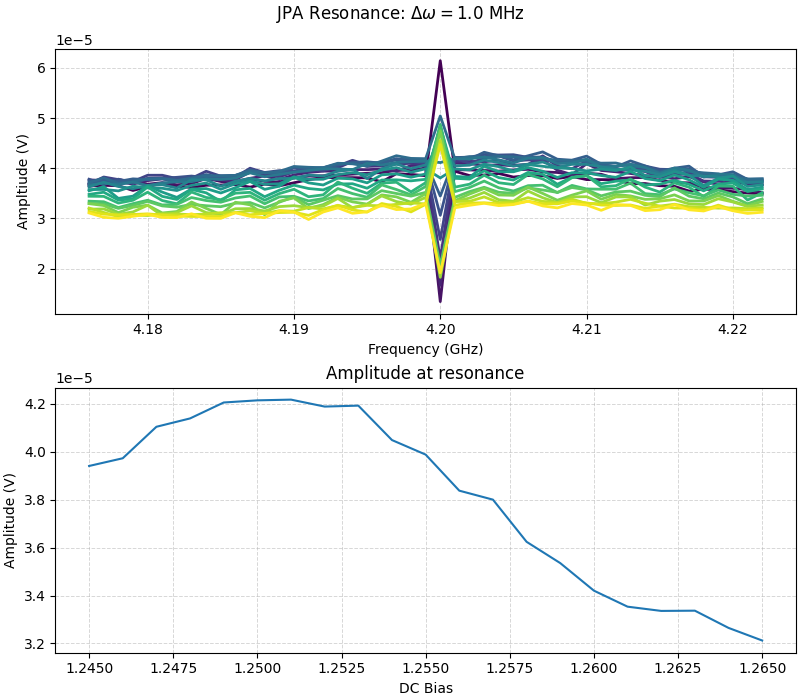

In [10]:
fig, ax = plt.subplots(nrows= 2, figsize=(8, 7), constrained_layout =True)


freq_idx = 25
print(freqs[freq_idx])

# Colormap and normalization
cmap = cm.viridis
norm = mcolors.Normalize(vmin=DC_Bias_list[0], vmax=DC_Bias_list[-1])

# Data
for bias_idx, bias_val in enumerate(DC_Bias_list):
    colors = cmap(norm(bias_val))
    ax[0].plot(
        freqs/1e9, 
        np.abs(resonance[bias_idx]), 
        label= f'DC Bias: {bias_val} V',
        color = colors,
        lw=2
        )
    
ax[1].plot(
        DC_Bias_list, 
        np.abs(resonance[:, freq_idx])
        )
ax[1].set_title('Amplitude at resonance')

# Grid and labels
ax[0].grid(ls='--', lw=0.7, alpha=0.5)
ax[1].grid(ls='--', lw=0.7, alpha=0.5)
ax[0].set_xlabel('Frequency (GHz)')
ax[0].set_ylabel('Ampltiude (V)')
ax[1].set_xlabel('DC Bias')
ax[1].set_ylabel('Amplitude (V)')

# plot limits
#ax[0].set_xlim(freq_centre/1e9, np.max(freqs)/1e9)
#ax[1].set_xlim(freq_centre/1e9, np.max(freqs)/1e9)

#ax[0].legend()
# --- ADD COLORBAR ---
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])   # required for older matplotlib versions
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label("Pump Amplitude (V)")



fig.suptitle(
    f'JPA Resonance: $\\Delta \\omega = ${df} MHz'
    ) 
# Save plot
#fig.savefig(f"Figures/LKIPA_Res_{df}_DCB_4_sig_0.3.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
np.argmax(resonance, axis=1)

array([33, 23, 23, 23, 36, 26, 26, 26, 26, 29, 29, 29, 29, 32, 32, 32, 32,
       32, 22, 32, 22])

<function matplotlib.pyplot.show(block=None)>

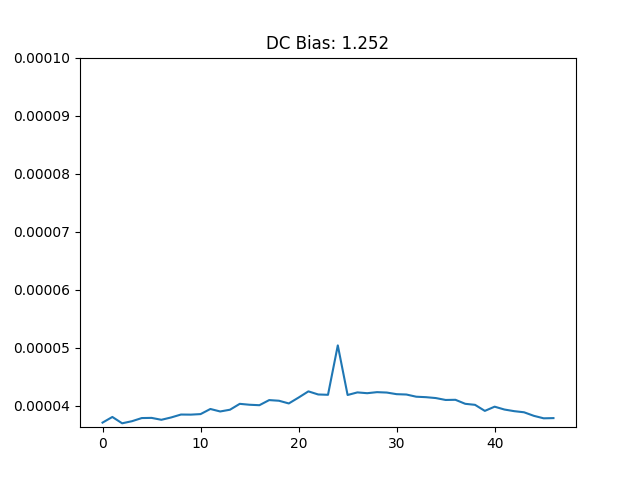

In [12]:
bias_idx=7

fig1, ax1= plt.subplots()
ax1.plot(np.abs(resonance[bias_idx]))
ax1.set_ylim(ymax=1e-4)
ax1.set_title(f'DC Bias: {DC_Bias_list[bias_idx]}')
ax
plt.show
